# Домашнее задание: Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели
## Занятие: Ансамбли моделей

* Будем работать в директории `homework_10`
* Используйте ноутбук `homework_10.ipynb` в директории `homework_10`

**Часть 1. EDA**

<br>

1. Скачайте данные с Kaggle по ценам на жильё в Airbnb в Нью-Йорке:
https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data
2. Пройдите по основным шагам работы с данными: 
    - выкиньте ненужные признаки: id, name, host_id, host_name, last_review
    - визуализируйте базовые статистики данных: распределения признаков, матрицу попарных корреляций, постройте pair plots
    - по результатам анализа произведите предобработку переменных

<br>

**Часть 2. Preprocessing & Feature Engineering**

<br>

Ваша цель — получить как можно более высокие метрики качества (можно взять несколько, R2, MAE, RMSE), сконцентрировавшись на преобразовании признаков.

<br>

Опробуйте различные техники:
   - работа с категориальными переменными (можно начать с dummy);
   - замена аномалий;
   - различные варианты шкалирования непрерывных переменных (StandardScaler, RobustScaler и т. д.);
   - обратите внимание на распределение целевой переменной, возможно, с ней тоже можно поработать;

<br>

Попробуйте на основании имеющихся переменных создать новые, которые могли бы улучшить качество модели. Например, можно найти координаты Манхэттена (самого дорогого района) и при помощи широты и долготы, а также евклидова расстояния создать новую переменную — расстояние от квартиры до этого района. Возможно, такой признак будет работать лучше, чем просто широта и долгота. 

<br>

**Часть 3. Моделирование**

<br>

1. Отложите 30% данных для тестирования.
2. Постройте модели простой линейной регрессии, RidgeCV, LassoCV и ElasticNetCV.
3. Измерьте качество каждой и визуализируйте важность признаков.
4. Сделайте интересные выводы :)

<br>

**В ноутбуке желательно видеть:**
1. Понятное описание: какие техники и алгоритмы были опробованы — было бы неплохо в самом начале тезисно выписать опробованные методики и их результат (помогло / не помогло).
2. Наличие визуализаций (не обязательно строить много графиков — можно несколько репрезентативных).
3. Наличие хотя бы одной модификации данных, приводящей к улучшению результатов.

In [1]:
          # Подключение библиотек 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

**Часть 1. EDA**

In [2]:
          # Загрузка набора данных
df_original = pd.read_csv("AB_NYC_2019.csv")
print(f"Размер набора: {df_original.shape}")
df_original.head()

Размер набора: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
          # Создание копии набора данных и удаление признаков, которые по условию не будут использоваться в моделировании
df = df_original.copy(deep = True)
df.drop(["id", "name", "host_id", "host_name", "last_review"], axis=1, inplace = True)
          # Удаление признака reviews_per_month, поскольку число месячных просмотров, скорее всего, не имеет значения при предсказании цен
df.drop(["reviews_per_month"], axis=1, inplace = True)
          # Удаление признака neighbourhood_group, поскольку он является более высоким иерархическим уровнем признака neighbourhood 
df.drop(["neighbourhood_group"], axis=1, inplace = True)
          # Удаление признаков географических координат, поскольку они отражают свойства объекта, оосредованно определяемыми признаком neighbourhood 
df.drop(["latitude", "longitude"], axis=1, inplace = True)
df.head()

,neighbourhood,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,Kensington,Private room,149,1,9,6,365
1,Midtown,Entire home/apt,225,1,45,2,355
2,Harlem,Private room,150,3,0,1,365
3,Clinton Hill,Entire home/apt,89,1,270,1,194
4,East Harlem,Entire home/apt,80,10,9,1,0


In [4]:
          # Проверка наличия пропусков в признаках для всего набора данных 
(round(df.isnull().sum() / df.shape[0] * 100, 2)).sort_values(ascending=False)

neighbourhood                     0.0
room_type                         0.0
price                             0.0
minimum_nights                    0.0
number_of_reviews                 0.0
calculated_host_listings_count    0.0
availability_365                  0.0
dtype: float64

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'calculated_host_listings_count'}>],
       [<Axes: title={'center': 'availability_365'}>, <Axes: >]],
      dtype=object)

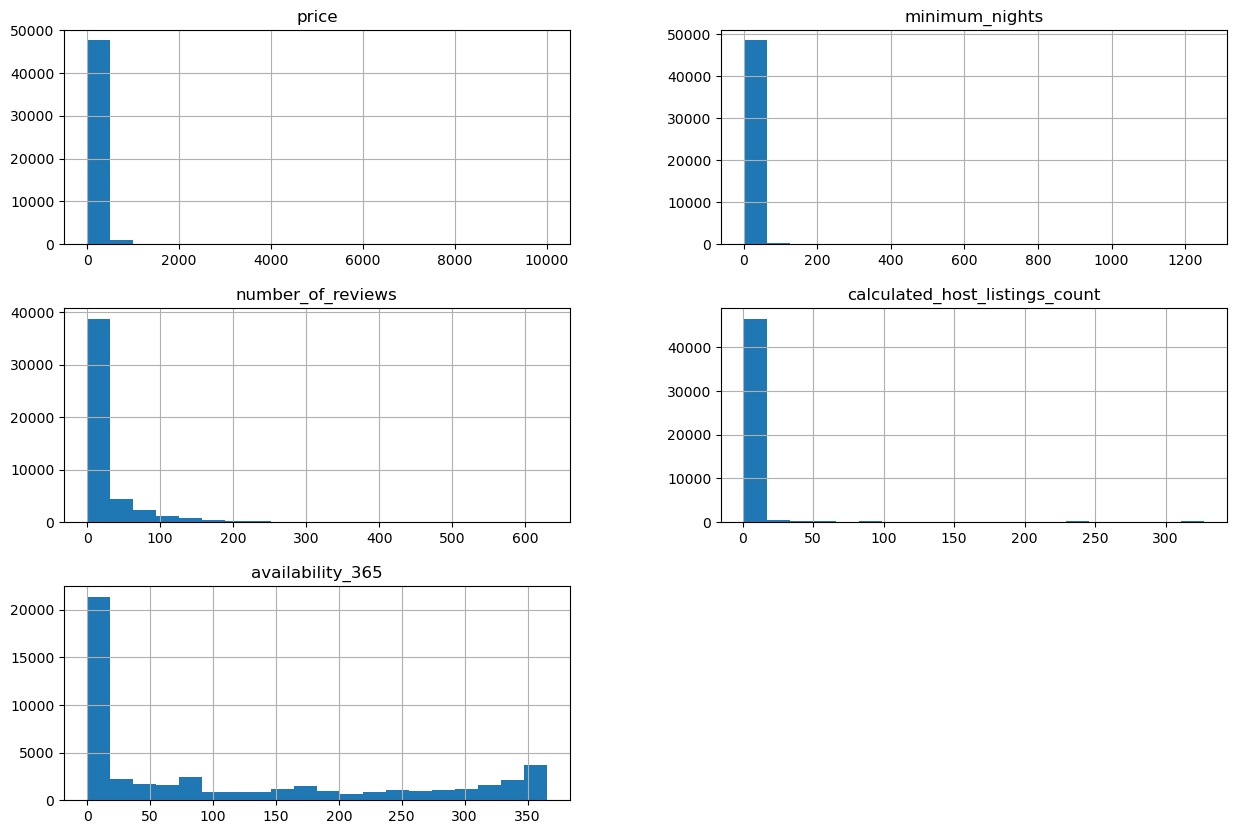

In [5]:
          # Оценка распределения признаков на гистограммах 
df.hist(bins=20, figsize=(15,10))

**Часть 2. Preprocessing & Feature Engineering**

In [6]:
          # Оценка статистики распределения числовых признаков 
df[["price", "minimum_nights", "number_of_reviews", "calculated_host_listings_count", "availability_365"]].describe()

,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,152.720687,7.029962,23.274466,7.143982,112.781327
std,240.154170,20.510550,44.550582,32.952519,131.622289
min,0.000000,1.000000,0.000000,1.000000,0.000000
25%,69.000000,1.000000,1.000000,1.000000,0.000000
50%,106.000000,3.000000,5.000000,1.000000,45.000000
75%,175.000000,5.000000,24.000000,2.000000,227.000000
max,10000.000000,1250.000000,629.000000,327.000000,365.000000


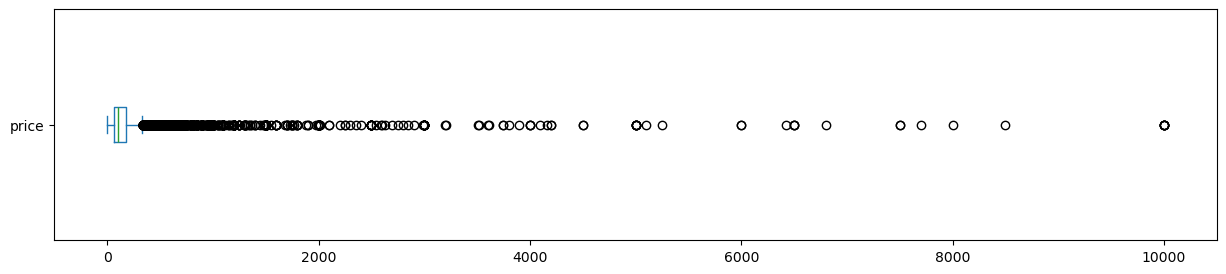

Сделки со стоимостью более 1000 USD: 239 , (0.4888%)
Сделки с нулевой стоимостью: 11 (0.0225%)


In [7]:
            # Проверка признака price c помощью диаграммы размаха
df["price"].plot(kind="box", vert=False, figsize=(15,3))
plt.show()
            # Подсчет количества и доли сделок с нулевой ценой и с ценой более 1000 USD
print("Сделки со стоимостью более 1000 USD:", len(df[df["price"] > 1000]), ", ({:.4f}%)".format((len(df[df["price"] > 1000]) / df.shape[0]) * 100))
print("Сделки с нулевой стоимостью:", len(df[df["price"] == 0]), "({:.4f}%)".format((len(df[df["price"] == 0]) / df.shape[0]) * 100))

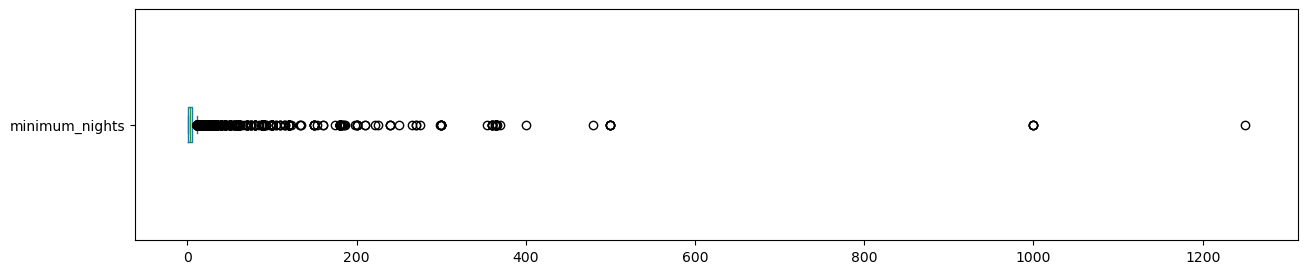

Сделки с минимальным числом ночей более 30: 747 , (1.5278%)


In [8]:
            # Проверка признака minimum_nights c помощью диаграммы размаха
df["minimum_nights"].plot(kind="box", vert=False, figsize=(15,3))
plt.show()
            # Подсчет количества и доли сделок с миримальным числом ночей ценой более 30
print("Сделки с минимальным числом ночей более 30:", len(df[df["minimum_nights"] > 30]), ", ({:.4f}%)".format((len(df[df["minimum_nights"] > 30]) / df.shape[0]) * 100))

In [9]:
           # Удаление сделок с нулевой стоимостью, стоимостью более 1000 USD, а также сделок с минимальным числом ночей более 30
df_before_shrinking = df.copy(deep = True)
print(df_before_shrinking.shape)
df = df[(df["price"] <= 1000) & (df["price"] > 0) & (df["minimum_nights"] <= 30)].copy()
print(df.shape)

(48895, 7)
(47924, 7)


In [10]:
df.describe()

,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
count,47924.000000,47924.000000,47924.000000,47924.000000,47924.000000
mean,141.314832,5.576016,23.540522,7.165074,111.434146
std,116.865661,8.195583,44.791982,33.125765,131.065255
min,10.000000,1.000000,0.000000,1.000000,0.000000
25%,69.000000,1.000000,1.000000,1.000000,0.000000
50%,105.000000,2.000000,5.000000,1.000000,43.000000
75%,175.000000,5.000000,24.000000,2.000000,223.000000
max,1000.000000,30.000000,629.000000,327.000000,365.000000


In [11]:
          # Замена текстовых признаков для проверки взаимных корреляций признаков с использованием матрицы корреляции (тепловой матрицы)
df["neighbourhood_numerized"] = df["neighbourhood"].apply(lambda x: df["neighbourhood"].value_counts().index.get_loc(x))
df["room_type_numerized"] = df["room_type"].apply(lambda x: df["room_type"].value_counts().index.get_loc(x))
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 47924 entries, 0 to 48894
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   neighbourhood                   47924 non-null  object
 1   room_type                       47924 non-null  object
 2   price                           47924 non-null  int64 
 3   minimum_nights                  47924 non-null  int64 
 4   number_of_reviews               47924 non-null  int64 
 5   calculated_host_listings_count  47924 non-null  int64 
 6   availability_365                47924 non-null  int64 
 7   neighbourhood_numerized         47924 non-null  int64 
 8   room_type_numerized             47924 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 3.7+ MB
None


,neighbourhood,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,neighbourhood_numerized,room_type_numerized
0,Kensington,Private room,149,1,9,6,365,51,1
1,Midtown,Entire home/apt,225,1,45,2,355,9,0
2,Harlem,Private room,150,3,0,1,365,2,1
3,Clinton Hill,Entire home/apt,89,1,270,1,194,19,0
4,East Harlem,Entire home/apt,80,10,9,1,0,11,0


In [12]:
           # Удаление текстовых признаков
df_before_heatmap = df.copy(deep = True)
print(df_before_heatmap.shape)
df.drop(["neighbourhood", "room_type"], axis=1, inplace = True)
print(df.shape)

(47924, 9)
(47924, 7)


                                   price  minimum_nights  number_of_reviews  \
price                           1.000000        0.044688          -0.058403   
minimum_nights                  0.044688        1.000000          -0.148529   
number_of_reviews              -0.058403       -0.148529           1.000000   
calculated_host_listings_count  0.129981        0.332261          -0.072810   
availability_365                0.117174        0.241308           0.178449   
neighbourhood_numerized        -0.073250       -0.061118           0.013170   

                                calculated_host_listings_count  \
price                                                 0.129981   
minimum_nights                                        0.332261   
number_of_reviews                                    -0.072810   
calculated_host_listings_count                        1.000000   
availability_365                                      0.228671   
neighbourhood_numerized                           

<Axes: >

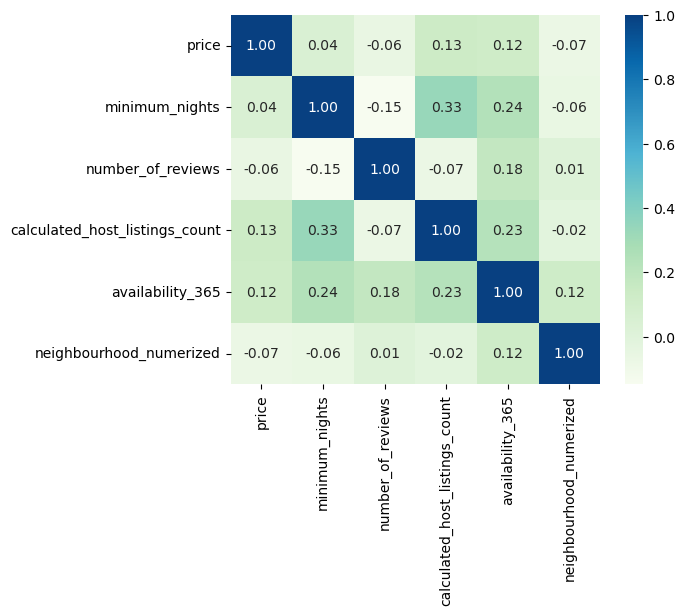

In [13]:
          # Проверка взаимных корреляций признаков с использованием матрицы корреляции (тепловой матрицы)
df_corr = df[["price", "minimum_nights", "number_of_reviews", "calculated_host_listings_count", "availability_365", "neighbourhood_numerized"]].corr()
print(df_corr)
sns.heatmap(df_corr, cmap='GnBu', fmt='.2f', square=True, linecolor='white', annot=True)

In [14]:
print(df['minimum_nights'].nunique(), df['number_of_reviews'].nunique(), df['availability_365'].nunique(), df['neighbourhood_numerized'].nunique() )

30 394 366 221


**Часть 3. Моделирование**

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>,
        <Axes: title={'center': 'number_of_reviews'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>,
        <Axes: title={'center': 'neighbourhood_numerized'}>],
       [<Axes: title={'center': 'room_type_numerized'}>, <Axes: >,
        <Axes: >]], dtype=object)

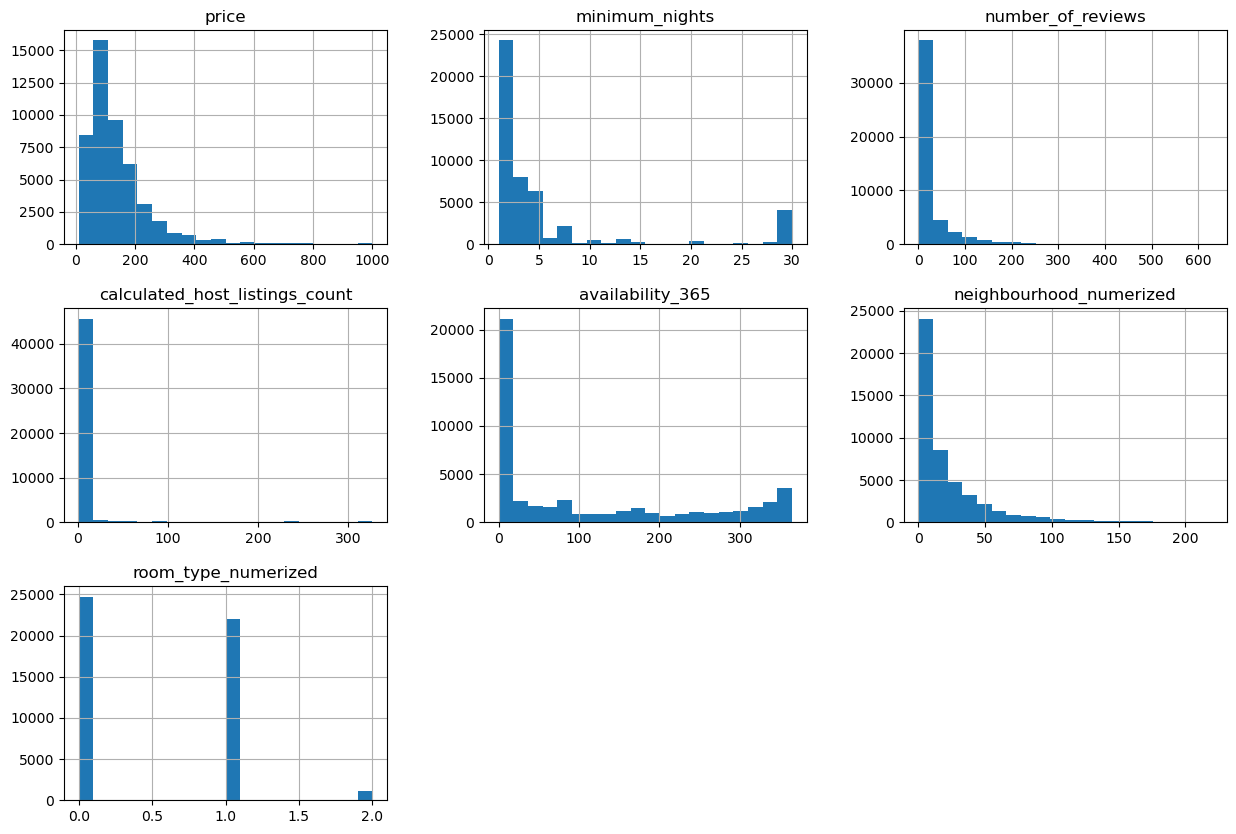

In [15]:
           # Оценка признаков перед моделированием
df.hist(bins=20, figsize=(15,10))

In [16]:
           # Разделение данных на признаки и целевую переменную
X = df.drop("price", axis=1)
y = df["price"]

In [17]:
           # Стандартизация признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [18]:
           # Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42)

In [19]:
           # Создание и обучение модели
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [20]:
           # Анализ коэффициентов модели
coefficients = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
coefficients = coefficients.sort_values("Coefficient", ascending=False)
print("Коэффициенты модели:")
print(coefficients)
print(f"Свободный член (Intercept): {model.intercept_:.4f}")

Коэффициенты модели:
                          Feature  Coefficient
3                availability_365    20.136173
2  calculated_host_listings_count     7.898863
4         neighbourhood_numerized   -10.077686
1               number_of_reviews   -11.465684
0                  minimum_nights   -11.661109
5             room_type_numerized   -55.108498
Свободный член (Intercept): 141.5433


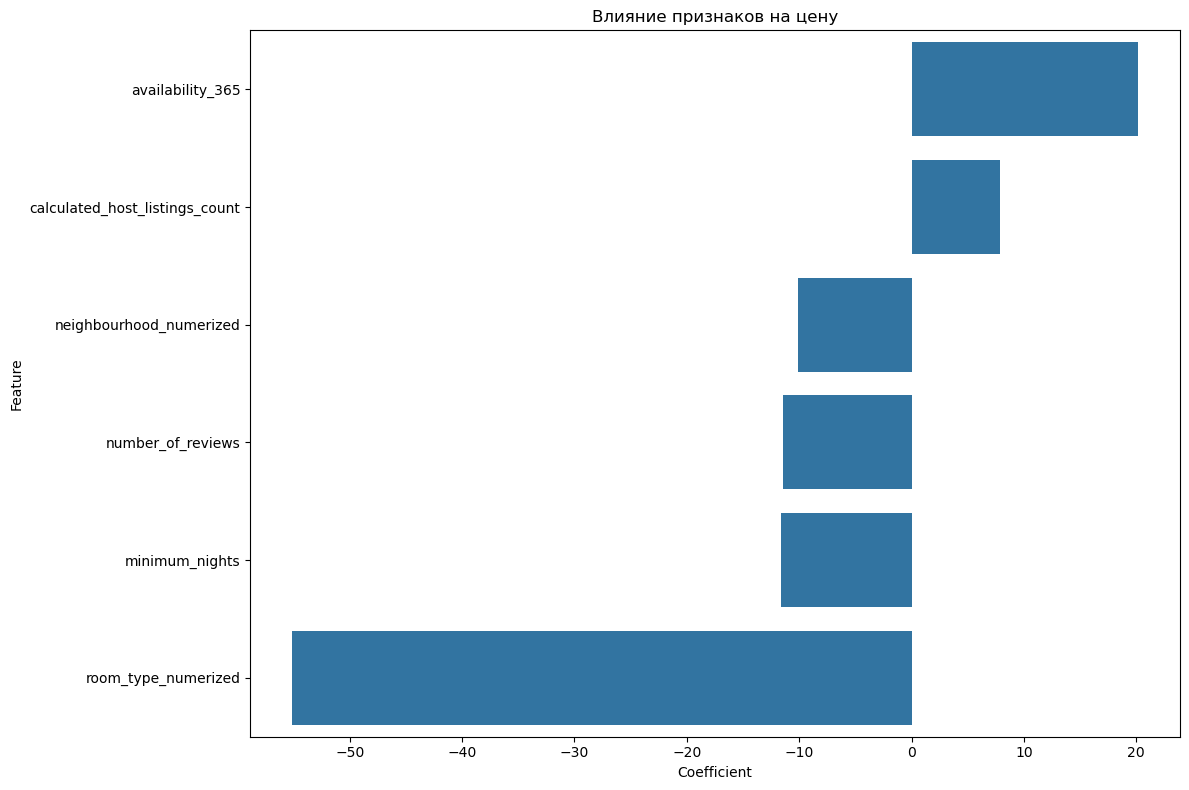

In [21]:
           # Визуализация влияния признаков
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=coefficients)
plt.title("Влияние признаков на цену")
plt.tight_layout()
plt.show()

In [22]:
           # Предсказание на обучающей и тестовой выборках
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [23]:
           # Расчет метрик качества
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"RMSE на обучающей выборке: {train_rmse:.4f}")
print(f"RMSE на тестовой выборке: {test_rmse:.4f}")
print(f"R² на обучающей выборке: {train_r2:.4f}")
print(f"R² на тестовой выборке: {test_r2:.4f}")

RMSE на обучающей выборке: 102.0824
RMSE на тестовой выборке: 98.4555
R² на обучающей выборке: 0.2504
R² на тестовой выборке: 0.2593


In [24]:
           # Оценка результатов предсказания
y_true = y_test
y_pred = model.predict(X_test)

In [25]:
           # Расчет основных метрик
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
adjusted_r2 = 1 - (1 - r2) * (len(y_true) - 1) / (len(y_true) - X_test.shape[1] - 1)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")
print(f"Скорректированный R²: {adjusted_r2:.4f}")

MSE: 9693.4857
RMSE: 98.4555
MAE: 60.4736
R²: 0.2593
Скорректированный R²: 0.2590


In [26]:
            # Настройка параметров для Ridge-регрессии
ridge_params = {"alpha": [.001, .01, 0.1, 1.0, 10.0, 100.0]}
ridge = Ridge()
ridge_gs = GridSearchCV(ridge, ridge_params, cv=5, scoring = "neg_mean_squared_error")
ridge_gs.fit(X_train, y_train)

print(f"Лучший параметр alpha для Ridge: {ridge_gs.best_params_["alpha"]}")
print(f"RMSE с оптимальной Ridge-регрессией: {np.sqrt(-ridge_gs.best_score_):.4f}")

Лучший параметр alpha для Ridge: 10.0
RMSE с оптимальной Ridge-регрессией: 102.1226


In [27]:
            # Настройка параметров для Lasso-регрессии
lasso_params = {"alpha": [.0001, 0.001, 0.01, 0.1, 1.0]}
lasso = Lasso(max_iter=10000)
lasso_gs = GridSearchCV(lasso, lasso_params, cv=5, scoring = "neg_mean_squared_error")
lasso_gs.fit(X_train, y_train)

print(f"Лучший параметр alpha для Lasso: {lasso_gs.best_params_["alpha"]}")
print(f"RMSE с оптимальной Lasso-регрессией: {np.sqrt(-lasso_gs.best_score_):.4f}")

Лучший параметр alpha для Lasso: 0.0001
RMSE с оптимальной Lasso-регрессией: 102.1226
